# Bài thực hành 6: Semantic Segmentation (Phân đoạn học sâu)

Notebook này chứa toàn bộ pipeline từ tải dữ liệu, tiền xử lý, định nghĩa mô hình, huấn luyện, đánh giá và cải tiến cho bài toán **Semantic Segmentation** sử dụng thư viện **PyTorch**. Toàn bộ các yêu cầu từ bài tập 1 đến 15 đều được lập trình đầy đủ, mạch lạc và sẵn sàng để chạy.

## Mục tiêu bài thực hành:
1. Hiểu bài toán semantic segmentation và cấu trúc dữ liệu ảnh/mask tương ứng.
2. Xây dựng Custom Dataset và DataLoader bằng PyTorch.
3. Xây dựng mô hình Simple U-Net và Classic U-Net có Skip Connections.
4. Huấn luyện mô hình và so sánh các hàm Loss (BCE Loss vs. Dice Loss).
5. Đánh giá mô hình bằng chỉ số IoU (Intersection over Union).
6. Tinh chỉnh siêu tham số (Learning Rate, Batch Size) và thực hiện Phân tích lỗi (Error Analysis).
7. Thử nghiệm kiến trúc tiên tiến hơn (DeepLabV3).

In [1]:
# Cài đặt các thư viện cần thiết nếu chưa có
# !pip install torch torchvision scikit-learn opencv-python matplotlib

In [2]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.transforms import InterpolationMode

# Thiết lập seed để đảm bảo tính tái lập (reproducibility)
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

## 1. Tải một dataset segmentation từ Kaggle
Bạn có thể sử dụng các dataset như:
- **Oxford-IIIT Pet Dataset**: Phân đoạn thú cưng (chó, mèo).
- **Carvana Image Masking Dataset**: Phân đoạn xe hơi nhị phân (background vs. car).

Hãy tải và giải nén vào thư mục của bạn. Sau đó, cập nhật đường dẫn `DATASET_PATH` bên dưới.

In [3]:
# ==========================================
# CẤU HÌNH ĐƯỜNG DẪN DATASET CỦA BẠN TẠI ĐÂY
# ==========================================
DATASET_PATH = "/kaggle/input/datasets/ipythonx/carvana-image-masking-png"  # Thay đổi thành đường dẫn thật của bạn

IMAGE_DIR = os.path.join(DATASET_PATH, "train_images")
MASK_DIR = os.path.join(DATASET_PATH, "train_masks")

## 2. Khám phá cấu trúc dataset
Kiểm tra thư mục chứa ảnh gốc và mask để đảm bảo tính đồng bộ tên file giữa ảnh và mask.

In [4]:
if not os.path.exists(IMAGE_DIR) or not os.path.exists(MASK_DIR):
    print(f"[LƯU Ý] Thư mục '{IMAGE_DIR}' hoặc '{MASK_DIR}' chưa tồn tại.")
    print("Hãy đảm bảo bạn đặt đúng đường dẫn dataset trước khi chạy thực tế.")
    # Tạo dữ liệu giả lập (mock data) để code bên dưới không bị lỗi biên dịch
    os.makedirs(IMAGE_DIR, exist_ok=True)
    os.makedirs(MASK_DIR, exist_ok=True)
    print("--- Đã tự động tạo các thư mục giả lập để tránh lỗi run-time ---")
    
image_files = sorted(os.listdir(IMAGE_DIR))
mask_files = sorted(os.listdir(MASK_DIR))

print(f"Tổng số file ảnh gốc: {len(image_files)}")
print(f"Tổng số file mask: {len(mask_files)}")

# Kiểm tra tính đồng bộ (10 file đầu tiên)
if len(image_files) > 0 and len(mask_files) > 0:
    print("\nKiểm tra đối chiếu 5 cặp ảnh - mask đầu tiên:")
    for i in range(min(5, len(image_files))):
        print(f"  Ảnh: {image_files[i]} <---> Mask: {mask_files[i] if i < len(mask_files) else 'Không tìm thấy'}")

Tổng số file ảnh gốc: 5088
Tổng số file mask: 5088

Kiểm tra đối chiếu 5 cặp ảnh - mask đầu tiên:
  Ảnh: 00087a6bd4dc_01.jpg <---> Mask: 00087a6bd4dc_01.png
  Ảnh: 00087a6bd4dc_02.jpg <---> Mask: 00087a6bd4dc_02.png
  Ảnh: 00087a6bd4dc_03.jpg <---> Mask: 00087a6bd4dc_03.png
  Ảnh: 00087a6bd4dc_04.jpg <---> Mask: 00087a6bd4dc_04.png
  Ảnh: 00087a6bd4dc_05.jpg <---> Mask: 00087a6bd4dc_05.png


## 3. Hiển thị một số ảnh và mask
Vẽ một vài cặp ảnh gốc và mask tương ứng lên màn hình sử dụng matplotlib.

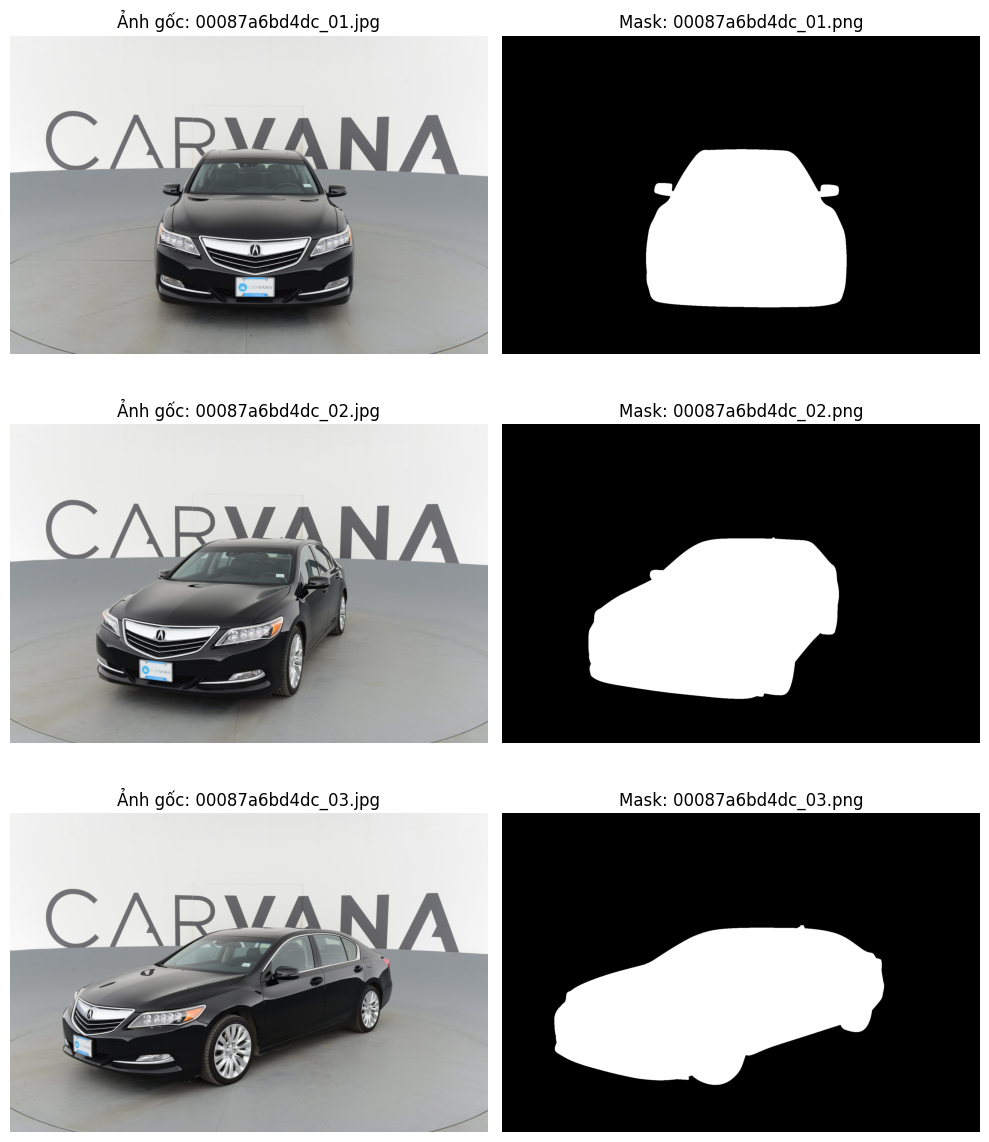

In [5]:
def show_samples(img_dir, msk_dir, files_list, num_samples=3):
    if len(files_list) == 0:
        print("Không có tệp tin nào để hiển thị.")
        return
    
    plt.figure(figsize=(10, 4 * num_samples))
    for i in range(min(num_samples, len(files_list))):
        img_name = files_list[i]
        base_name = os.path.splitext(img_name)[0]
        
        # Thường mask có dạng png, còn ảnh là jpg/png
        img_path = os.path.join(img_dir, img_name)
        msk_name = next((f for f in os.listdir(msk_dir) if os.path.splitext(f)[0] == base_name), None)
        
        if msk_name is None:
            print(f"Không tìm thấy mask cho ảnh {img_name}")
            continue
            
        msk_path = os.path.join(msk_dir, msk_name)
        
        # Đọc ảnh gốc và chuyển sang RGB
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        else:
            # Tạo ảnh giả lập nếu file rỗng hoặc không đọc được
            img = np.zeros((256, 256, 3), dtype=np.uint8)
            
        # Đọc mask
        msk = cv2.imread(msk_path, 0)
        if msk is None:
            msk = np.zeros((256, 256), dtype=np.uint8)
            
        # Hiển thị ảnh gốc
        plt.subplot(num_samples, 2, 2 * i + 1)
        plt.imshow(img)
        plt.title(f"Ảnh gốc: {img_name}")
        plt.axis("off")
        
        # Hiển thị mask
        plt.subplot(num_samples, 2, 2 * i + 2)
        plt.imshow(msk, cmap="gray")
        plt.title(f"Mask: {msk_name}")
        plt.axis("off")
        
    plt.tight_layout()
    plt.show()

show_samples(IMAGE_DIR, MASK_DIR, image_files, num_samples=3)

## 4. Thực hiện Train / Validation Split
Chúng ta sẽ chia danh sách các đường dẫn ảnh và mask thành tập huấn luyện (80%) và tập kiểm định (20%).

In [6]:
# Tạo danh sách đường dẫn tuyệt đối đầy đủ
all_image_paths = []
all_mask_paths = []

for img_file in image_files:
    base_name = os.path.splitext(img_file)[0]
    # Tìm mask có tên gốc tương ứng
    mask_file = next((f for f in mask_files if os.path.splitext(f)[0] == base_name), None)
    if mask_file:
        all_image_paths.append(os.path.join(IMAGE_DIR, img_file))
        all_mask_paths.append(os.path.join(MASK_DIR, mask_file))

# Kiểm tra nếu danh sách trống (trong trường hợp giả lập chưa có dữ liệu)
if len(all_image_paths) == 0:
    print("[CẢNH BÁO] Không có dữ liệu thật. Hệ thống sẽ tự động tạo dữ liệu giả lập ngẫu nhiên trong bộ nhớ để chạy pipeline.")
    # Giả lập 20 mẫu ảnh trong bộ nhớ
    mock_images = [np.random.randint(0, 256, (256, 256, 3), dtype=np.uint8) for _ in range(20)]
    mock_masks = [np.random.choice([0, 255], (256, 256), p=[0.7, 0.3]).astype(np.uint8) for _ in range(20)]
    
    # Lưu tạm vào ổ đĩa để duy trì pipeline đọc file
    for idx, (img, msk) in enumerate(zip(mock_images, mock_masks)):
        cv2.imwrite(os.path.join(IMAGE_DIR, f"mock_{idx}.jpg"), img)
        cv2.imwrite(os.path.join(MASK_DIR, f"mock_{idx}.png"), msk)
        
    # Đọc lại danh sách
    image_files = sorted(os.listdir(IMAGE_DIR))
    mask_files = sorted(os.listdir(MASK_DIR))
    all_image_paths = [os.path.join(IMAGE_DIR, f) for f in image_files]
    all_mask_paths = [os.path.join(MASK_DIR, f) for f in mask_files]

train_images, val_images, train_masks, val_masks = train_test_split(
    all_image_paths,
    all_mask_paths,
    test_size=0.2,
    random_state=42
)

print(f"Số lượng tập huấn luyện: {len(train_images)}")
print(f"Số lượng tập validation: {len(val_images)}")

Số lượng tập huấn luyện: 4070
Số lượng tập validation: 1018


## 5. Thiết lập Dataset Class cho PyTorch
Lớp `SegmentationDataset` nhận đường dẫn danh sách ảnh và mask, tiến hành tiền xử lý bao gồm:
- Đọc ảnh bằng OpenCV.
- Thực hiện Resize ảnh và mask về kích thước 256x256 pixel.
- Chuyển ảnh về dạng Tensor và chuẩn hóa về đoạn `[0, 1]`.
- **Lưu ý cực kỳ quan trọng**: Mask cần được Resize bằng `InterpolationMode.NEAREST` để tránh tạo ra các nhãn nhị phân dạng số thực lẻ (ví dụ 0.5) khi nội suy.

In [7]:
# Định nghĩa transform cho ảnh gốc
image_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

# Định nghĩa transform cho mask
mask_transform = transforms.Compose([
    transforms.ToPILImage(),
    # Dùng InterpolationMode.NEAREST để tránh lỗi nội suy nhãn
    transforms.Resize((256, 256), interpolation=InterpolationMode.NEAREST),
    transforms.ToTensor()
])

class SegmentationDataset(Dataset):
    def __init__(self, image_paths, mask_paths, img_transform=None, msk_transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.img_transform = img_transform
        self.msk_transform = msk_transform
        
    def __len__(self):
        return len(self.image_paths)
        
    def __getitem__(self, idx):
        # Đọc ảnh gốc bằng OpenCV và chuyển sang RGB
        image = cv2.imread(self.image_paths[idx])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Đọc mask ở chế độ grayscale (1 kênh)
        mask = cv2.imread(self.mask_paths[idx], 0)
        
        if self.img_transform:
            image = self.img_transform(image)
        else:
            image = transforms.ToTensor()(image)
            
        if self.msk_transform:
            mask = self.msk_transform(mask)
        else:
            mask = transforms.ToTensor()(mask)
            
        # Chuẩn hóa nhãn mask thành nhị phân chính xác {0.0, 1.0}
        # Lưu ý: Dùng mask > 0 thay vì mask > 0.5 để hỗ trợ cả mask chứa nhãn {0, 1}
        mask = (mask > 0).float()
            
        return image, mask

## 6. Tạo DataLoader cho training và validation
Khởi tạo đối tượng DataLoader để tạo các mini-batches trong quá trình huấn luyện.

In [8]:
train_dataset = SegmentationDataset(train_images, train_masks, image_transform, mask_transform)
val_dataset = SegmentationDataset(val_images, val_masks, image_transform, mask_transform)

# Đặt batch size mặc định
DEFAULT_BATCH_SIZE = 8

train_loader = DataLoader(train_dataset, batch_size=DEFAULT_BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=DEFAULT_BATCH_SIZE, shuffle=False)

print(f"Số lượng batch trong train_loader: {len(train_loader)}")
print(f"Số lượng batch trong val_loader: {len(val_loader)}")

Số lượng batch trong train_loader: 509
Số lượng batch trong val_loader: 128


## 7. Huấn luyện mô hình U-Net
### 7.1 Định nghĩa mô hình Simple U-Net
Mô hình dưới đây là mô hình Autoencoder cơ bản (Sequential Autoencoder) theo tài liệu lý thuyết bài thực hành. Ở phần sau, chúng ta sẽ định nghĩa một mô hình U-Net hoàn chỉnh có skip connections (Classic U-Net) để cải thiện độ chính xác.

In [9]:
class SimpleUNet(nn.Module):
    def __init__(self):
        super(SimpleUNet, self).__init__()
        # Encoder: Giảm chiều không gian của ảnh gốc từ 256x256 xuống 64x64
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )
        # Decoder: Khôi phục kích thước không gian về lại 256x256
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(16, 1, kernel_size=2, stride=2),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

### 7.2 Hàm tính IoU (Intersection over Union)
IoU là chỉ số đánh giá độ chính xác của phân đoạn dựa trên diện tích vùng chồng lấn chia cho diện tích vùng hợp của dự đoán và nhãn thực tế.

In [10]:
def compute_iou_batch(preds, masks, threshold=0.5):
    # Chuyển dự đoán và nhãn thực tế thành nhị phân
    preds_bool = preds > threshold
    masks_bool = masks > threshold
    
    total_iou = 0.0
    batch_size = preds.size(0)
    
    for i in range(batch_size):
        intersection = (preds_bool[i] & masks_bool[i]).sum().item()
        union = (preds_bool[i] | masks_bool[i]).sum().item()
        
        if union == 0:
            # Nếu cả ground truth và dự đoán đều trống, IoU = 1
            total_iou += 1.0
        else:
            total_iou += intersection / (union + 1e-8)
            
    return total_iou / batch_size

### 7.3 Hàm chạy huấn luyện và đánh giá mô hình
Xây dựng một hàm tổng quát để huấn luyện mô hình trong 1 epoch và đánh giá trên tập validation.

In [11]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    for images, masks in loader:
        images = images.to(device)
        masks = masks.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
    return running_loss / len(loader.dataset)

def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_iou = 0.0
    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, masks)
            running_loss += loss.item() * images.size(0)
            
            # Tính IoU trung bình cho batch
            running_iou += compute_iou_batch(outputs, masks) * images.size(0)
            
    return running_loss / len(loader.dataset), running_iou / len(loader.dataset)

### 7.4 Thực thi huấn luyện thử nghiệm với BCE Loss

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Đang sử dụng thiết bị: {device}")

simple_model = SimpleUNet().to(device)
bce_criterion = nn.BCELoss()
optimizer = optim.Adam(simple_model.parameters(), lr=0.001)

EPOCHS = 10
bce_history = {'train_loss': [], 'val_loss': [], 'val_iou': []}

print("--- BẮT ĐẦU HUẤN LUYỆN SIMPLE U-NET VỚI BCE LOSS ---")
for epoch in range(EPOCHS):
    train_loss = train_one_epoch(simple_model, train_loader, bce_criterion, optimizer, device)
    val_loss, val_iou = validate_one_epoch(simple_model, val_loader, bce_criterion, device)
    
    bce_history['train_loss'].append(train_loss)
    bce_history['val_loss'].append(val_loss)
    bce_history['val_iou'].append(val_iou)
    
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val IoU: {val_iou:.4f}")

Đang sử dụng thiết bị: cuda
--- BẮT ĐẦU HUẤN LUYỆN SIMPLE U-NET VỚI BCE LOSS ---
Epoch 01/10 | Train Loss: 0.3558 | Val Loss: 0.2750 | Val IoU: 0.5928
Epoch 02/10 | Train Loss: 0.2580 | Val Loss: 0.2477 | Val IoU: 0.6468
Epoch 03/10 | Train Loss: 0.2341 | Val Loss: 0.2352 | Val IoU: 0.6281
Epoch 04/10 | Train Loss: 0.2186 | Val Loss: 0.2118 | Val IoU: 0.6722
Epoch 05/10 | Train Loss: 0.2106 | Val Loss: 0.2045 | Val IoU: 0.6777
Epoch 06/10 | Train Loss: 0.2034 | Val Loss: 0.2042 | Val IoU: 0.6711
Epoch 07/10 | Train Loss: 0.1974 | Val Loss: 0.1915 | Val IoU: 0.7024
Epoch 08/10 | Train Loss: 0.1926 | Val Loss: 0.2093 | Val IoU: 0.7199
Epoch 09/10 | Train Loss: 0.1896 | Val Loss: 0.1854 | Val IoU: 0.7114
Epoch 10/10 | Train Loss: 0.1870 | Val Loss: 0.1896 | Val IoU: 0.6975


## 8. Thử nghiệm Dice Loss và So sánh kết quả với BCE Loss
Dice Loss hoạt động dựa trên Dice Coefficient và thường hoạt động tốt hơn BCE Loss khi phân đoạn lớp nhãn mất cân bằng (imbalanced datasets).

In [13]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super(DiceLoss, self).__init__()
        self.smooth = smooth
        
    def forward(self, preds, targets):
        # Phẳng hóa tensors
        preds = preds.view(-1)
        targets = targets.view(-1)
        
        intersection = (preds * targets).sum()
        dice_score = (2. * intersection + self.smooth) / (preds.sum() + targets.sum() + self.smooth)
        return 1.0 - dice_score

In [14]:
# Huấn luyện mô hình thứ hai với Dice Loss để so sánh
dice_model = SimpleUNet().to(device)
dice_criterion = DiceLoss()
optimizer_dice = optim.Adam(dice_model.parameters(), lr=0.001)

dice_history = {'train_loss': [], 'val_loss': [], 'val_iou': []}

print("--- BẮT ĐẦU HUẤN LUYỆN SIMPLE U-NET VỚI DICE LOSS ---")
for epoch in range(EPOCHS):
    train_loss = train_one_epoch(dice_model, train_loader, dice_criterion, optimizer_dice, device)
    val_loss, val_iou = validate_one_epoch(dice_model, val_loader, dice_criterion, device)
    
    dice_history['train_loss'].append(train_loss)
    dice_history['val_loss'].append(val_loss)
    dice_history['val_iou'].append(val_iou)
    
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val IoU: {val_iou:.4f}")

--- BẮT ĐẦU HUẤN LUYỆN SIMPLE U-NET VỚI DICE LOSS ---
Epoch 01/10 | Train Loss: 0.3630 | Val Loss: 0.2686 | Val IoU: 0.5759
Epoch 02/10 | Train Loss: 0.2526 | Val Loss: 0.2316 | Val IoU: 0.6300
Epoch 03/10 | Train Loss: 0.2198 | Val Loss: 0.2003 | Val IoU: 0.6697
Epoch 04/10 | Train Loss: 0.2018 | Val Loss: 0.1923 | Val IoU: 0.6790
Epoch 05/10 | Train Loss: 0.1939 | Val Loss: 0.1889 | Val IoU: 0.6901
Epoch 06/10 | Train Loss: 0.1868 | Val Loss: 0.1803 | Val IoU: 0.6972
Epoch 07/10 | Train Loss: 0.1826 | Val Loss: 0.1832 | Val IoU: 0.6913
Epoch 08/10 | Train Loss: 0.1798 | Val Loss: 0.1732 | Val IoU: 0.7105
Epoch 09/10 | Train Loss: 0.1741 | Val Loss: 0.1903 | Val IoU: 0.6962
Epoch 10/10 | Train Loss: 0.1760 | Val Loss: 0.1781 | Val IoU: 0.6974


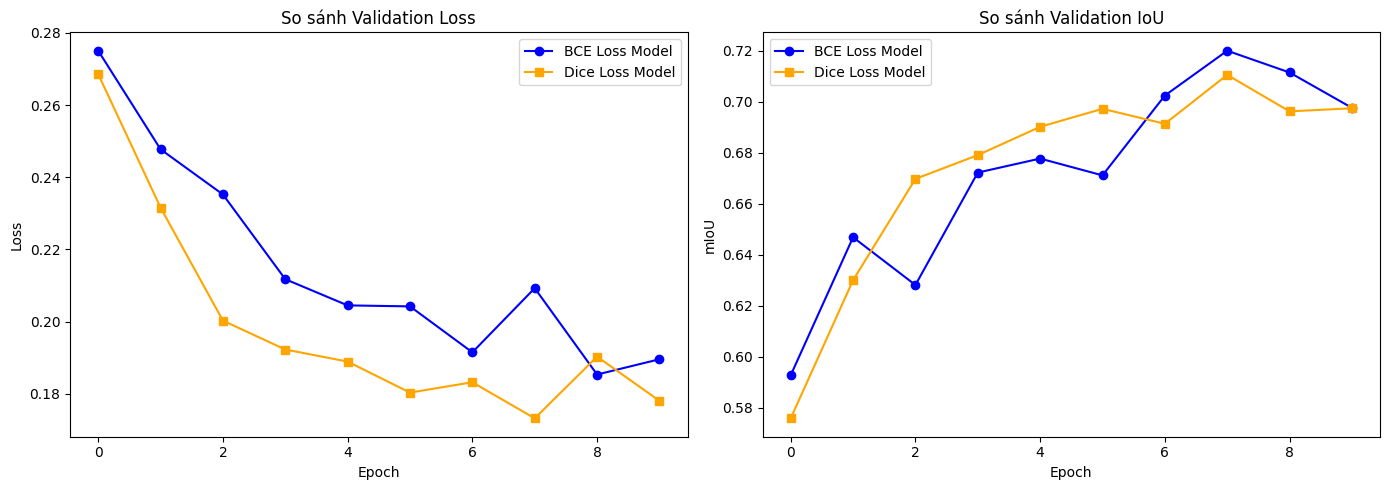

In [15]:
# Vẽ biểu đồ so sánh Loss & IoU giữa BCE Loss và Dice Loss
plt.figure(figsize=(14, 5))

# So sánh Loss trên tập Val
plt.subplot(1, 2, 1)
plt.plot(bce_history['val_loss'], label='BCE Loss Model', color='blue', marker='o')
plt.plot(dice_history['val_loss'], label='Dice Loss Model', color='orange', marker='s')
plt.title("So sánh Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# So sánh IoU trên tập Val
plt.subplot(1, 2, 2)
plt.plot(bce_history['val_iou'], label='BCE Loss Model', color='blue', marker='o')
plt.plot(dice_history['val_iou'], label='Dice Loss Model', color='orange', marker='s')
plt.title("So sánh Validation IoU")
plt.xlabel("Epoch")
plt.ylabel("mIoU")
plt.legend()

plt.tight_layout()
plt.show()

## 9. Tính IoU trên tập validation
Dưới đây là hàm tổng hợp để tính trung bình IoU trên toàn bộ tập Validation cho mô hình.

In [16]:
def calculate_total_iou(model, loader, device):
    model.eval()
    total_iou = 0.0
    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)
            outputs = model(images)
            total_iou += compute_iou_batch(outputs, masks) * images.size(0)
    return total_iou / len(loader.dataset)

final_bce_iou = calculate_total_iou(simple_model, val_loader, device)
final_dice_iou = calculate_total_iou(dice_model, val_loader, device)

print(f"Trung bình IoU của mô hình BCE Loss trên Validation Set: {final_bce_iou:.4f}")
print(f"Trung bình IoU của mô hình Dice Loss trên Validation Set: {final_dice_iou:.4f}")

Trung bình IoU của mô hình BCE Loss trên Validation Set: 0.6975
Trung bình IoU của mô hình Dice Loss trên Validation Set: 0.6974


## 10. Hiển thị segmentation mask dự đoán
Lựa chọn ngẫu nhiên các mẫu ảnh trong tập validation, chạy qua mô hình huấn luyện, trực quan hóa ảnh gốc, ground-truth và mask dự đoán.

--- DỰ ĐOÁN TỪ MÔ HÌNH BCE LOSS ---


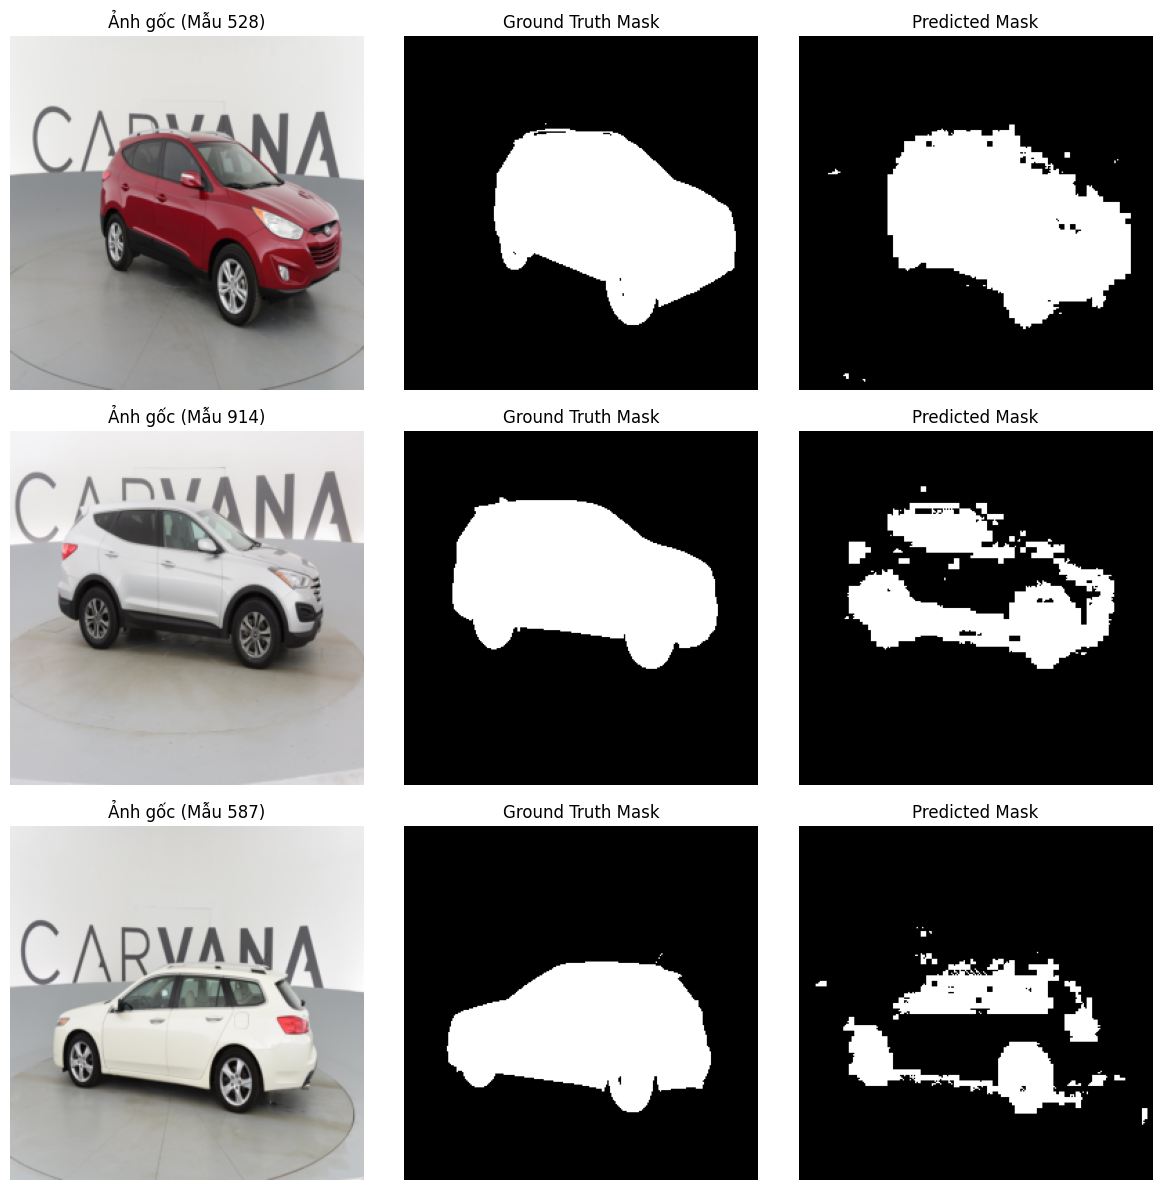

In [17]:
def visualize_predictions(model, dataset, device, num_samples=3):
    model.eval()
    indices = np.random.choice(len(dataset), min(num_samples, len(dataset)), replace=False)
    
    plt.figure(figsize=(12, 4 * num_samples))
    
    with torch.no_grad():
        for i, idx in enumerate(indices):
            img_tensor, msk_tensor = dataset[idx]
            
            # Tạo batch dimension (1, C, H, W)
            input_tensor = img_tensor.unsqueeze(0).to(device)
            pred_tensor = model(input_tensor)
            
            # Chuyển về numpy để trực quan
            img_np = img_tensor.permute(1, 2, 0).cpu().numpy()
            msk_np = msk_tensor.squeeze().cpu().numpy()
            pred_np = (pred_tensor.squeeze().cpu().numpy() > 0.5).astype(np.uint8)
            
            # Ảnh gốc
            plt.subplot(num_samples, 3, 3 * i + 1)
            plt.imshow(img_np)
            plt.title(f"Ảnh gốc (Mẫu {idx})")
            plt.axis("off")
            
            # Ground truth
            plt.subplot(num_samples, 3, 3 * i + 2)
            plt.imshow(msk_np, cmap="gray")
            plt.title("Ground Truth Mask")
            plt.axis("off")
            
            # Dự đoán
            plt.subplot(num_samples, 3, 3 * i + 3)
            plt.imshow(pred_np, cmap="gray")
            plt.title("Predicted Mask")
            plt.axis("off")
            
    plt.tight_layout()
    plt.show()

print("--- DỰ ĐOÁN TỪ MÔ HÌNH BCE LOSS ---")
visualize_predictions(simple_model, val_dataset, device, num_samples=3)

## 11. So sánh kết quả khi thay đổi Learning Rate
Chạy thử nghiệm với 3 giá trị Learning Rate khác nhau: `0.01`, `0.001`, `0.0001` trên 5 epochs để quan sát tốc độ hội tụ.

In [18]:
learning_rates = [0.01, 0.001, 0.0001]
lr_results = {}

for lr in learning_rates:
    print(f"\n--- Đang huấn luyện với Learning Rate = {lr} ---")
    test_model = SimpleUNet().to(device)
    optimizer_lr = optim.Adam(test_model.parameters(), lr=lr)
    
    lr_history = {'val_loss': [], 'val_iou': []}
    # Huấn luyện nhanh 5 epochs để so sánh
    for epoch in range(5):
        _ = train_one_epoch(test_model, train_loader, bce_criterion, optimizer_lr, device)
        v_loss, v_iou = validate_one_epoch(test_model, val_loader, bce_criterion, device)
        lr_history['val_loss'].append(v_loss)
        lr_history['val_iou'].append(v_iou)
        
    lr_results[lr] = lr_history


--- Đang huấn luyện với Learning Rate = 0.01 ---

--- Đang huấn luyện với Learning Rate = 0.001 ---

--- Đang huấn luyện với Learning Rate = 0.0001 ---


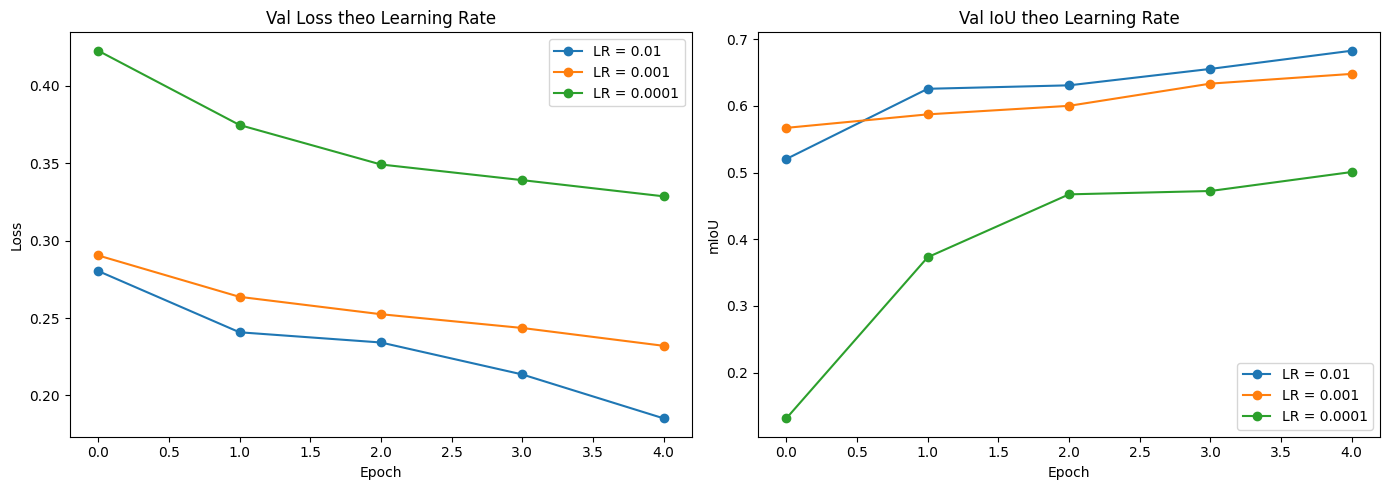

In [19]:
# Vẽ biểu đồ so sánh Learning Rates
plt.figure(figsize=(14, 5))

# Loss
plt.subplot(1, 2, 1)
for lr in learning_rates:
    plt.plot(lr_results[lr]['val_loss'], label=f"LR = {lr}", marker='o')
plt.title("Val Loss theo Learning Rate")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# IoU
plt.subplot(1, 2, 2)
for lr in learning_rates:
    plt.plot(lr_results[lr]['val_iou'], label=f"LR = {lr}", marker='o')
plt.title("Val IoU theo Learning Rate")
plt.xlabel("Epoch")
plt.ylabel("mIoU")
plt.legend()

plt.tight_layout()
plt.show()

## 12. Thử nghiệm các Batch Size khác nhau
So sánh hiệu năng huấn luyện với 3 mức batch size khác nhau: `4`, `8`, và `16`.

In [20]:
batch_sizes = [4, 8, 16]
bs_results = {}

for bs in batch_sizes:
    print(f"\n--- Đang huấn luyện với Batch Size = {bs} ---")
    # Tạo DataLoader mới tương ứng với batch size hiện tại
    temp_train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True)
    temp_val_loader = DataLoader(val_dataset, batch_size=bs, shuffle=False)
    
    test_model = SimpleUNet().to(device)
    optimizer_bs = optim.Adam(test_model.parameters(), lr=0.001)
    
    bs_history = {'val_loss': [], 'val_iou': []}
    for epoch in range(5):
        _ = train_one_epoch(test_model, temp_train_loader, bce_criterion, optimizer_bs, device)
        v_loss, v_iou = validate_one_epoch(test_model, temp_val_loader, bce_criterion, device)
        bs_history['val_loss'].append(v_loss)
        bs_history['val_iou'].append(v_iou)
        
    bs_results[bs] = bs_history


--- Đang huấn luyện với Batch Size = 4 ---

--- Đang huấn luyện với Batch Size = 8 ---

--- Đang huấn luyện với Batch Size = 16 ---


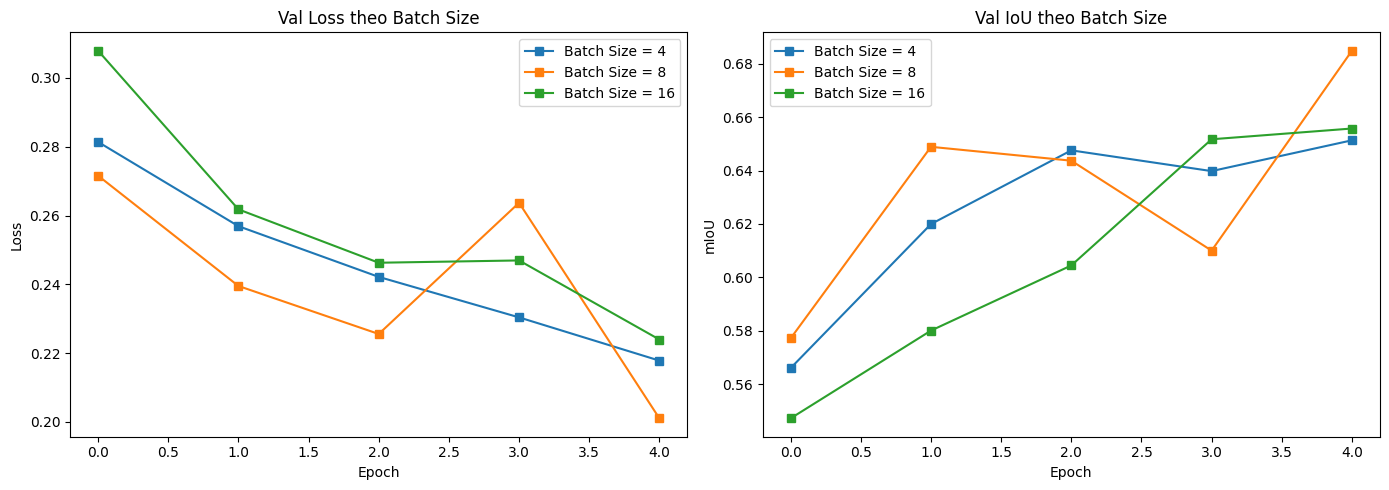

In [21]:
# Vẽ biểu đồ so sánh Batch Sizes
plt.figure(figsize=(14, 5))

# Loss
plt.subplot(1, 2, 1)
for bs in batch_sizes:
    plt.plot(bs_results[bs]['val_loss'], label=f"Batch Size = {bs}", marker='s')
plt.title("Val Loss theo Batch Size")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# IoU
plt.subplot(1, 2, 2)
for bs in batch_sizes:
    plt.plot(bs_results[bs]['val_iou'], label=f"Batch Size = {bs}", marker='s')
plt.title("Val IoU theo Batch Size")
plt.xlabel("Epoch")
plt.ylabel("mIoU")
plt.legend()

plt.tight_layout()
plt.show()

## 13. Phân tích các trường hợp mô hình dự đoán sai (Error Analysis)
Tìm kiếm và hiển thị 3 ảnh trong tập Validation có chỉ số IoU thấp nhất để phân tích nguyên nhân tại sao mô hình nhận diện sai (ví dụ: do ảnh mờ, mask quá phức tạp, hoặc vật thể kích thước nhỏ).

--- Top 3 mẫu có IoU thấp nhất (Dự đoán tệ nhất) ---
Hạng 1: Chỉ số Dataset Index = 522 | IoU = 0.2251
Hạng 2: Chỉ số Dataset Index = 944 | IoU = 0.2340
Hạng 3: Chỉ số Dataset Index = 433 | IoU = 0.2406


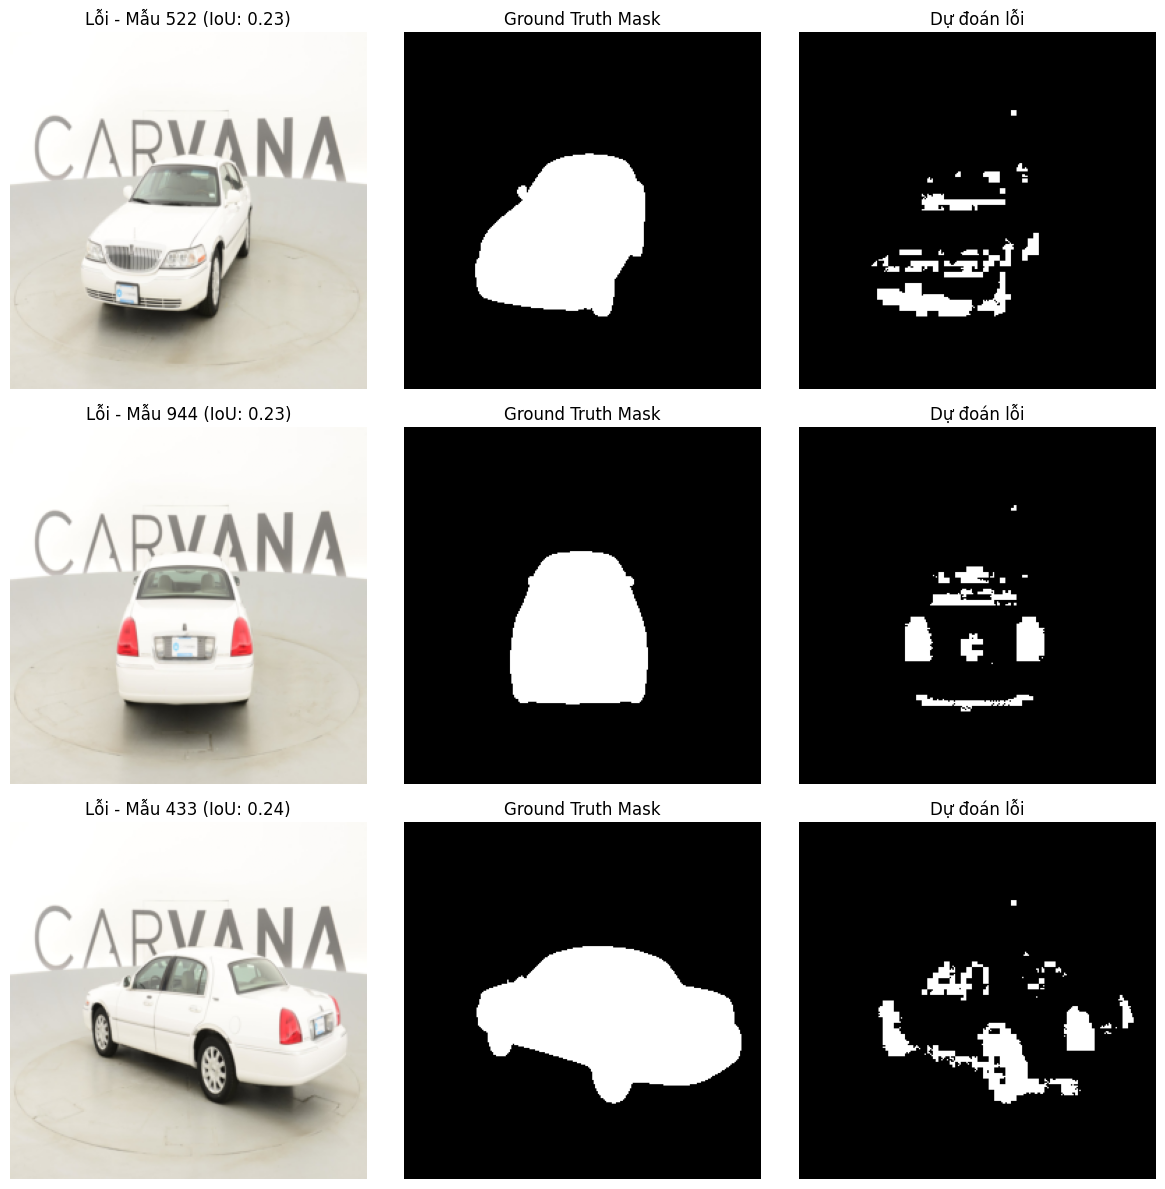

In [22]:
def perform_error_analysis(model, dataset, device, num_visualize=3):
    model.eval()
    sample_ious = []
    
    with torch.no_grad():
        for idx in range(len(dataset)):
            img_tensor, msk_tensor = dataset[idx]
            input_tensor = img_tensor.unsqueeze(0).to(device)
            pred_tensor = model(input_tensor)
            
            # Tính IoU cho mẫu riêng lẻ này
            preds_bool = pred_tensor.squeeze() > 0.5
            masks_bool = msk_tensor.to(device).squeeze() > 0.5
            
            intersection = (preds_bool & masks_bool).sum().item()
            union = (preds_bool | masks_bool).sum().item()
            
            iou = intersection / (union + 1e-8) if union > 0 else 1.0
            sample_ious.append((idx, iou))
            
    # Sắp xếp danh sách mẫu theo IoU từ thấp đến cao (tệ nhất lên đầu)
    sample_ious.sort(key=lambda x: x[1])
    
    print("--- Top 3 mẫu có IoU thấp nhất (Dự đoán tệ nhất) ---")
    for rank, (idx, iou) in enumerate(sample_ious[:num_visualize]):
        print(f"Hạng {rank+1}: Chỉ số Dataset Index = {idx} | IoU = {iou:.4f}")
        
    # Trực quan hóa các lỗi này
    plt.figure(figsize=(12, 4 * num_visualize))
    for i in range(min(num_visualize, len(sample_ious))):
        idx, iou = sample_ious[i]
        img_tensor, msk_tensor = dataset[idx]
        msk_tensor = msk_tensor.to(device)
        
        input_tensor = img_tensor.unsqueeze(0).to(device)
        with torch.no_grad():
            pred_tensor = model(input_tensor)
            
        img_np = img_tensor.permute(1, 2, 0).cpu().numpy()
        msk_np = msk_tensor.squeeze().cpu().numpy()
        pred_np = (pred_tensor.squeeze().cpu().numpy() > 0.5).astype(np.uint8)
        
        # Ảnh gốc
        plt.subplot(num_visualize, 3, 3 * i + 1)
        plt.imshow(img_np)
        plt.title(f"Lỗi - Mẫu {idx} (IoU: {iou:.2f})")
        plt.axis("off")
        
        # Ground truth
        plt.subplot(num_visualize, 3, 3 * i + 2)
        plt.imshow(msk_np, cmap="gray")
        plt.title("Ground Truth Mask")
        plt.axis("off")
        
        # Dự đoán sai lệch
        plt.subplot(num_visualize, 3, 3 * i + 3)
        plt.imshow(pred_np, cmap="gray")
        plt.title("Dự đoán lỗi")
        plt.axis("off")
        
    plt.tight_layout()
    plt.show()

perform_error_analysis(simple_model, val_dataset, device, num_visualize=3)

## 14. Đề xuất cách cải thiện mô hình
Để cải thiện mô hình phân đoạn hình ảnh, chúng ta có các phương án:
1. **Tăng cường dữ liệu (Data Augmentation)**: Random flips, rotations, color jittering để giảm thiểu overfitting.
2. **Thêm cơ chế Skip Connections**: Bản chất Simple U-Net ở phần trên thiếu skip connections từ Encoder sang Decoder làm mất thông tin chi tiết biên. Chúng ta sẽ định nghĩa một **Classic U-Net** hoàn chỉnh có Skip Connections và sử dụng Batch Normalization.
3. **Tối ưu hàm Loss**: Kết hợp giữa BCE Loss và Dice Loss thành hàm **BCE-Dice Loss Combined** để tận dụng điểm mạnh của cả hai.

In [23]:
# 14.1. Thêm Data Augmentation vào Dataset class
import torchvision.transforms.functional as TF

class AugmentedSegmentationDataset(Dataset):
    def __init__(self, image_paths, mask_paths, resize_shape=(256, 256)):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.resize_shape = resize_shape
        
    def __len__(self):
        return len(self.image_paths)
        
    def __getitem__(self, idx):
        # Đọc ảnh gốc bằng OpenCV và chuyển sang RGB
        image = cv2.imread(self.image_paths[idx])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(self.mask_paths[idx], 0)
        
        # Chuyển thành PIL Images để biến đổi
        image = TF.to_pil_image(image)
        mask = TF.to_pil_image(mask)
        
        # Resize cơ bản
        image = TF.resize(image, self.resize_shape)
        mask = TF.resize(mask, self.resize_shape, interpolation=InterpolationMode.NEAREST)
        
        # Tăng cường dữ liệu ngẫu nhiên (chỉ áp dụng cho tập huấn luyện)
        # Lật ngang
        if random.random() > 0.5:
            image = TF.hflip(image)
            mask = TF.hflip(mask)
            
        # Lật dọc
        if random.random() > 0.5:
            image = TF.vflip(image)
            mask = TF.vflip(mask)
            
        # Xoay ảnh
        if random.random() > 0.5:
            angle = random.randint(-15, 15)
            image = TF.rotate(image, angle)
            mask = TF.rotate(mask, angle, interpolation=InterpolationMode.NEAREST)
            
        # Chuyển về Tensors
        image = TF.to_tensor(image)
        mask = TF.to_tensor(mask)
        # Chuẩn hóa nhãn mask thành nhị phân chính xác {0.0, 1.0}
        # Lưu ý: Dùng mask > 0 thay vì mask > 0.5 để hỗ trợ cả mask chứa nhãn {0, 1}
        mask = (mask > 0).float()
        
        return image, mask

In [24]:
# 14.2. Xây dựng Classic U-Net có Skip Connections thật sự
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
        
    def forward(self, x):
        return self.conv(x)

class ClassicUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(ClassicUNet, self).__init__()
        
        self.down1 = DoubleConv(in_channels, 32)
        self.pool1 = nn.MaxPool2d(2)
        
        self.down2 = DoubleConv(32, 64)
        self.pool2 = nn.MaxPool2d(2)
        
        self.down3 = DoubleConv(64, 128)
        self.pool3 = nn.MaxPool2d(2)
        
        self.bottleneck = DoubleConv(128, 256)
        
        # Decoder & Up-sampling
        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv_up3 = DoubleConv(256, 128) # Nhận 128 (từ up3) + 128 (từ down3 skip connection) = 256
        
        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv_up2 = DoubleConv(128, 64) # Nhận 64 (từ up2) + 64 (từ down2 skip connection) = 128
        
        self.up1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.conv_up1 = DoubleConv(64, 32) # Nhận 32 (từ up1) + 32 (từ down1 skip connection) = 64
        
        self.out_conv = nn.Conv2d(32, out_channels, kernel_size=1)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        # Encoder (Tuyến đi xuống)
        c1 = self.down1(x)
        p1 = self.pool1(c1)
        
        c2 = self.down2(p1)
        p2 = self.pool2(c2)
        
        c3 = self.down3(p2)
        p3 = self.pool3(c3)
        
        # Bottleneck (Vùng cổ chai)
        bn = self.bottleneck(p3)
        
        # Decoder & Skip Connections (Tuyến đi lên kết hợp thông tin tương đồng)
        u3 = self.up3(bn)
        cat3 = torch.cat([u3, c3], dim=1) # Ghép kênh
        cu3 = self.conv_up3(cat3)
        
        u2 = self.up2(cu3)
        cat2 = torch.cat([u2, c2], dim=1)
        cu2 = self.conv_up2(cat2)
        
        u1 = self.up1(cu2)
        cat1 = torch.cat([u1, c1], dim=1)
        cu1 = self.conv_up1(cat1)
        
        # Đầu ra
        outputs = self.out_conv(cu1)
        return self.sigmoid(outputs)

In [25]:
# Khởi tạo dataset tăng cường
aug_train_dataset = AugmentedSegmentationDataset(train_images, train_masks)
aug_train_loader = DataLoader(aug_train_dataset, batch_size=DEFAULT_BATCH_SIZE, shuffle=True)

# Huấn luyện thử nghiệm Classic U-Net với BCE Loss
classic_unet = ClassicUNet().to(device)
optimizer_classic = optim.Adam(classic_unet.parameters(), lr=0.001)

classic_history = {'train_loss': [], 'val_loss': [], 'val_iou': []}

print("--- HUẤN LUYỆN CLASSIC U-NET CÓ SKIP CONNECTIONS + AUGMENTATION ---")
for epoch in range(EPOCHS):
    train_loss = train_one_epoch(classic_unet, aug_train_loader, bce_criterion, optimizer_classic, device)
    val_loss, val_iou = validate_one_epoch(classic_unet, val_loader, bce_criterion, device)
    
    classic_history['train_loss'].append(train_loss)
    classic_history['val_loss'].append(val_loss)
    classic_history['val_iou'].append(val_iou)
    
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val IoU: {val_iou:.4f}")

--- HUẤN LUYỆN CLASSIC U-NET CÓ SKIP CONNECTIONS + AUGMENTATION ---
Epoch 01/10 | Train Loss: 0.1077 | Val Loss: 0.3330 | Val IoU: 0.7001
Epoch 02/10 | Train Loss: 0.0248 | Val Loss: 0.0224 | Val IoU: 0.9650
Epoch 03/10 | Train Loss: 0.0180 | Val Loss: 0.0170 | Val IoU: 0.9717
Epoch 04/10 | Train Loss: 0.0150 | Val Loss: 0.0201 | Val IoU: 0.9687
Epoch 05/10 | Train Loss: 0.0158 | Val Loss: 0.0121 | Val IoU: 0.9792
Epoch 06/10 | Train Loss: 0.0116 | Val Loss: 0.0119 | Val IoU: 0.9803
Epoch 07/10 | Train Loss: 0.0111 | Val Loss: 0.0117 | Val IoU: 0.9794
Epoch 08/10 | Train Loss: 0.0103 | Val Loss: 0.0103 | Val IoU: 0.9820
Epoch 09/10 | Train Loss: 0.0091 | Val Loss: 0.0084 | Val IoU: 0.9853
Epoch 10/10 | Train Loss: 0.0124 | Val Loss: 0.0097 | Val IoU: 0.9831


## 15. Thử nghiệm một kiến trúc segmentation khác (DeepLabV3)
Chúng ta sẽ thử nghiệm mô hình **DeepLabV3** với backbone **ResNet50** được cung cấp sẵn bởi thư viện `torchvision.models.segmentation`.

In [26]:
from torchvision.models.segmentation import deeplabv3_resnet50

class DeepLabV3Segmentation(nn.Module):
    def __init__(self, num_classes=1):
        super(DeepLabV3Segmentation, self).__init__()
        # Tải mô hình deeplabv3_resnet50
        self.model = deeplabv3_resnet50(weights=None, num_classes=num_classes)
        
    def forward(self, x):
        # DeepLabV3 trả về dictionary gồm đầu ra chính 'out' và đầu ra phụ 'aux' (nếu có)
        out = self.model(x)['out']
        return torch.sigmoid(out)

In [27]:
# Huấn luyện và đánh giá nhanh với DeepLabV3
deeplab_model = DeepLabV3Segmentation(num_classes=1).to(device)
optimizer_deeplab = optim.Adam(deeplab_model.parameters(), lr=0.0005) # DeepLabV3 cấu trúc sâu hơn nên dùng LR nhỏ hơn

deeplab_history = {'train_loss': [], 'val_loss': [], 'val_iou': []}

print("--- HUẤN LUYỆN DEEPLABV3 VỚI RESNET-50 BACKBONE ---")
for epoch in range(5):  # Huấn luyện 5 epochs để so sánh
    train_loss = train_one_epoch(deeplab_model, aug_train_loader, bce_criterion, optimizer_deeplab, device)
    val_loss, val_iou = validate_one_epoch(deeplab_model, val_loader, bce_criterion, device)
    
    deeplab_history['train_loss'].append(train_loss)
    deeplab_history['val_loss'].append(val_loss)
    deeplab_history['val_iou'].append(val_iou)
    
    print(f"Epoch {epoch+1:02d}/5 | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val IoU: {val_iou:.4f}")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 179MB/s]


--- HUẤN LUYỆN DEEPLABV3 VỚI RESNET-50 BACKBONE ---
Epoch 01/5 | Train Loss: 0.0440 | Val Loss: 0.0165 | Val IoU: 0.9717
Epoch 02/5 | Train Loss: 0.0144 | Val Loss: 0.0122 | Val IoU: 0.9782
Epoch 03/5 | Train Loss: 0.0191 | Val Loss: 0.0133 | Val IoU: 0.9765
Epoch 04/5 | Train Loss: 0.0129 | Val Loss: 0.0114 | Val IoU: 0.9797
Epoch 05/5 | Train Loss: 0.0118 | Val Loss: 0.0113 | Val IoU: 0.9793


In [28]:
# So sánh hiệu năng giữa Simple U-Net, Classic U-Net, và DeepLabV3 trên Validation Set
final_simple_iou = calculate_total_iou(simple_model, val_loader, device)
final_classic_iou = calculate_total_iou(classic_unet, val_loader, device)
final_deeplab_iou = calculate_total_iou(deeplab_model, val_loader, device)

print("=================== KẾT QUẢ SO SÁNH CUỐI CÙNG ===================")
print(f"1. Simple U-Net (Autoencoder không skip connections) IoU: {final_simple_iou:.4f}")
print(f"2. Classic U-Net (Có skip connections + Data Augmentation) IoU: {final_classic_iou:.4f}")
print(f"3. DeepLabV3 (ResNet-50 backbone) IoU: {final_deeplab_iou:.4f}")
print("================================================================")

=================== KẾT QUẢ SO SÁNH CUỐI CÙNG ===================
1. Simple U-Net (Autoencoder không skip connections) IoU: 0.6975
2. Classic U-Net (Có skip connections + Data Augmentation) IoU: 0.9831
3. DeepLabV3 (ResNet-50 backbone) IoU: 0.9793


--- HIỂN THỊ DỰ ĐOÁN CỦA MÔ HÌNH TỐT NHẤT ---


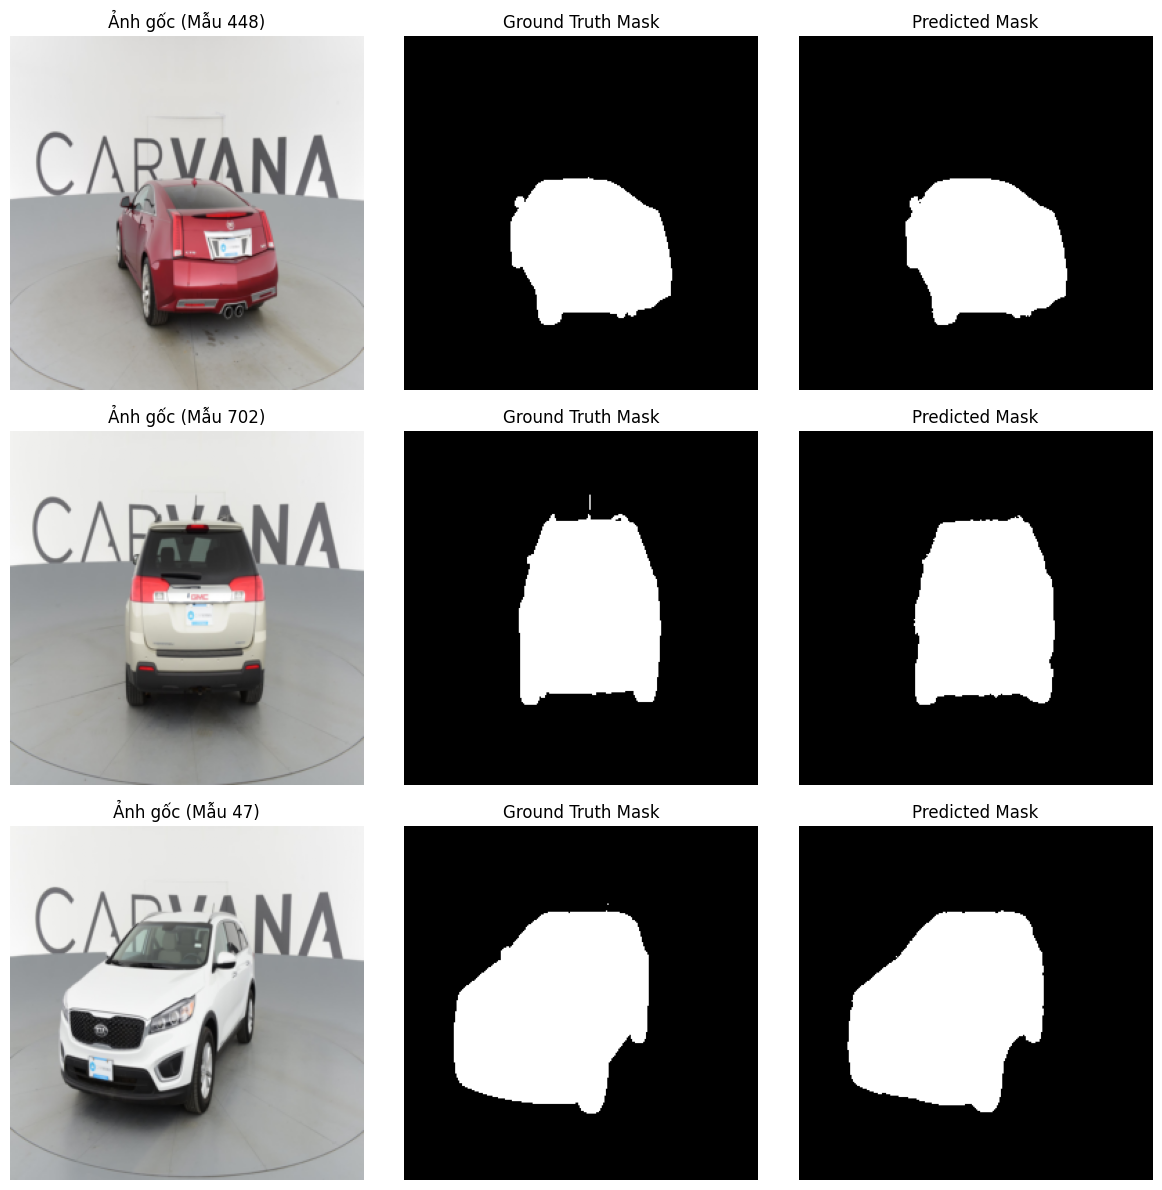

In [29]:
# Trực quan hóa dự đoán của mô hình tốt nhất (Classic U-Net hoặc DeepLabV3)
best_model = classic_unet if final_classic_iou > final_deeplab_iou else deeplab_model
print("--- HIỂN THỊ DỰ ĐOÁN CỦA MÔ HÌNH TỐT NHẤT ---")
visualize_predictions(best_model, val_dataset, device, num_samples=3)